

SESSION 13 - Data Visualization with Seaborn (Part 2)Topics Covered:Pairplot for quick multivariate analysisHeatmaps for correlation analysisrelplot, catplot,
displotJointplotscatter + histregression line fitVisualizing group trendsbar + confidence intervals


TASKS


In [4]:
import seaborn as sns 
import pandas as pd
import numpy as np

In [40]:
import matplotlib.pyplot as plt



1. Load the 'tips' dataset from Seaborn and create a pairplot to quickly visualize relationships between all numeric variables.


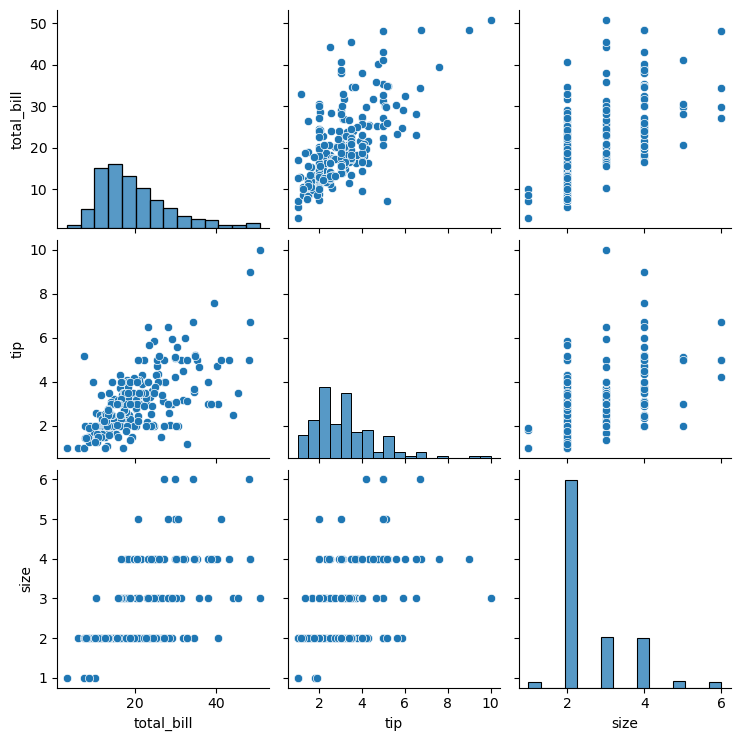

In [2]:
dataset = sns.load_dataset("tips")
sns.pairplot(dataset)

2. Using the 'flights' dataset from Seaborn, generate a heatmap showing the correlation between months and years based on the number of passengers.

        Hint: Use pivot_table to reshape the data before plotting the heatmap.


In [5]:
dataset2 = sns.load_dataset("flights")


In [6]:
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [9]:
dataset2.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [16]:
pivoted_value = dataset2.pivot_table(index= "month", columns= "year" , aggfunc= sum )
pivoted_value2 = dataset2.pivot_table(index = "year" , columns = "month" , aggfunc= sum)

C:\Users\Dell\AppData\Local\Temp\ipykernel_11784\1969209751.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivoted_value = dataset2.pivot_table(index= "month", columns= "year" , aggfunc= sum )
C:\Users\Dell\AppData\Local\Temp\ipykernel_11784\1969209751.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pivoted_value = dataset2.pivot_table(index= "month", columns= "year" , aggfunc= sum )
C:\Users\Dell\AppData\Local\Temp\ipykernel_11784\1969209751.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and reta

<Axes: xlabel='None-year', ylabel='month'>

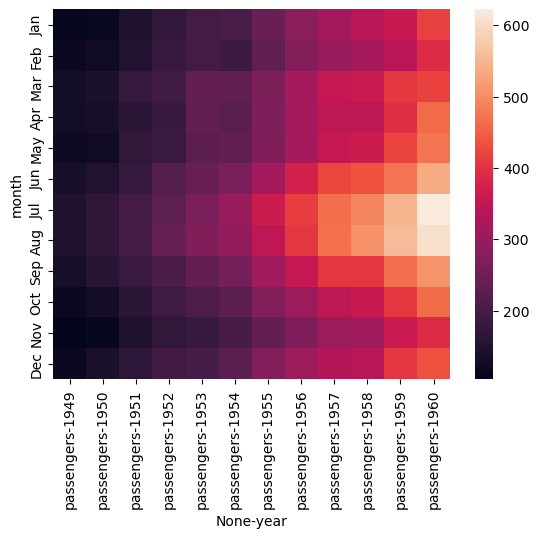

In [15]:
sns.heatmap(pivoted_value)

<Axes: xlabel='None-month', ylabel='year'>

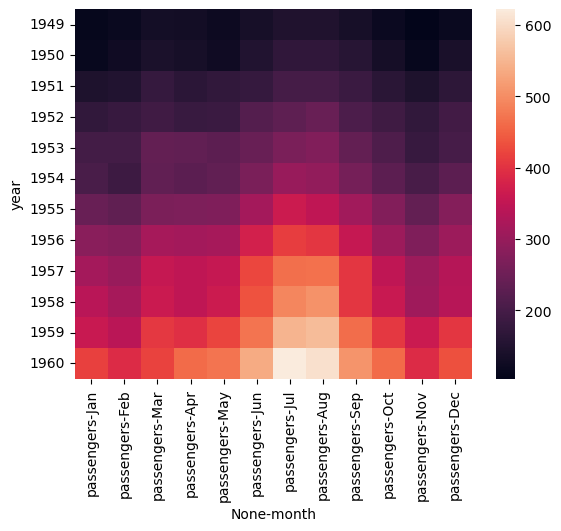

In [17]:
sns.heatmap(pivoted_value2)

3. Create a relplot using the 'fmri' dataset from Seaborn to visualize how the signal changes over time for different event types.


In [18]:
dataset3 = sns.load_dataset("fmri")

In [19]:
dataset3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subject    1064 non-null   object 
 1   timepoint  1064 non-null   int64  
 2   event      1064 non-null   object 
 3   region     1064 non-null   object 
 4   signal     1064 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 41.7+ KB


In [20]:
dataset3

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970
...,...,...,...,...,...
1059,s0,8,cue,frontal,0.018165
1060,s13,7,cue,frontal,-0.029130
1061,s12,7,cue,frontal,-0.004939
1062,s11,7,cue,frontal,-0.025367


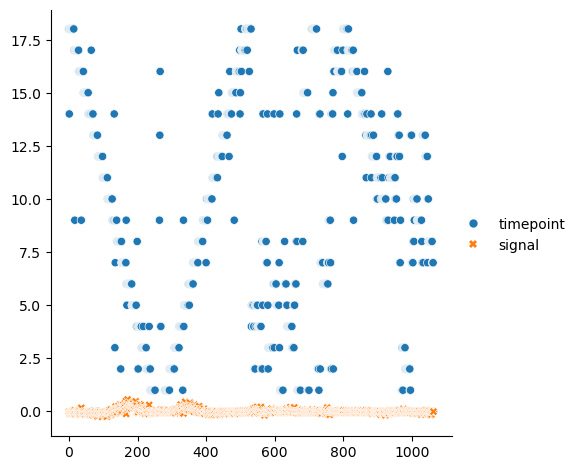

In [21]:
sns.relplot(dataset3)

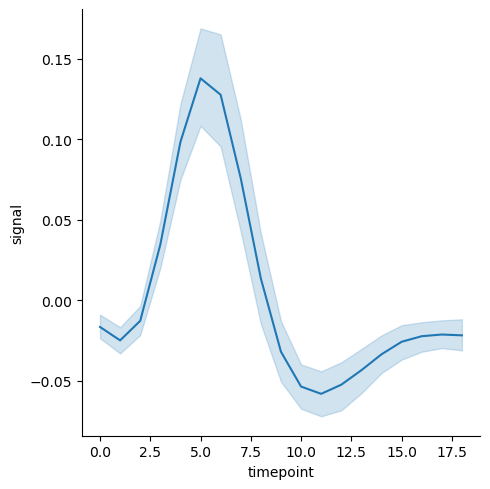

In [26]:
sns.relplot(dataset3 ,  x ="timepoint" , y = "signal", kind = "line")

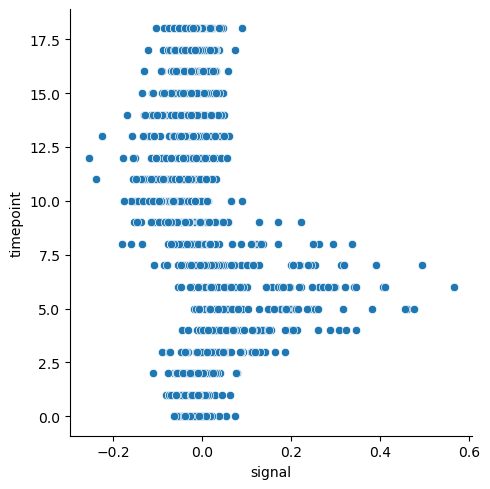

In [27]:
sns.relplot(dataset3 ,  x ="signal" , y = "timepoint" , kind = "scatter")


4. Pick any categorical column from the 'titanic' dataset (like 'class' or 'sex') and use catplot to display the survival rate for each group with confidence intervals.


In [ ]:
dataset3 = pd.read_csv("F:/Tops_assignment/Python_Library/datasets/titanic/test.csv")

In [32]:
dataset3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


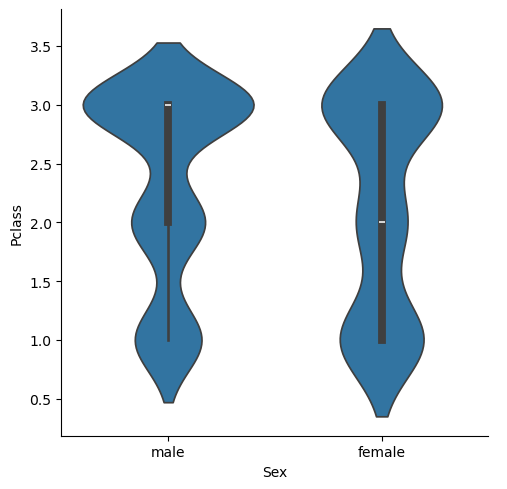

In [38]:
sns.catplot(dataset3 , x = "Sex" , y = "Pclass" , kind= "violin")

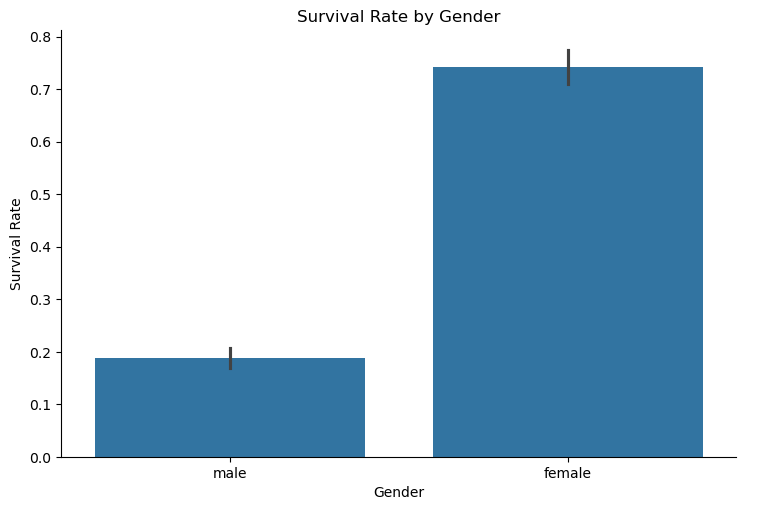

In [45]:
#chatgpt
# Load Titanic dataset
titanic = sns.load_dataset("titanic")

# Catplot showing survival rate by sex
sns.catplot(
    data=titanic,
    x="sex",
    y="survived",
    kind="bar",
    errorbar=("ci", 80),  # 95% confidence interval
    height=5,
    aspect=1.5
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

5. Use jointplot on the 'penguins' dataset to visualize the relationship between bill_length_mm and flipper_length_mm, and fit a regression line on the scatter plot.

        Hint: Set kind='reg' in jointplot for regression line.



In [46]:
dataset4 = sns.load_dataset("penguins")

In [47]:
dataset4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

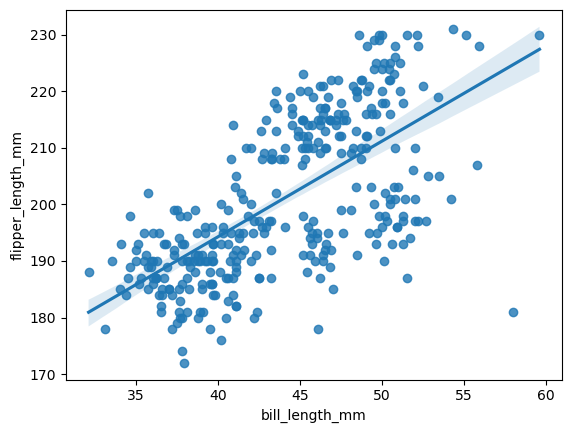

In [48]:
sns.regplot(dataset4 , x= "bill_length_mm" , y = "flipper_length_mm")